## 0. Downloading and Process the Data

In [ ]:
!pip install --quiet opendatasets

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import opendatasets as od
import seaborn as sns
import plotly.express as px

In [ ]:
od.download("https://www.kaggle.com/competitions/rossmann-store-sales/data")

Skipping, found downloaded files in "./rossmann-store-sales" (use force=True to force download)


In [ ]:
os.listdir("rossmann-store-sales")

['store.csv', 'sample_submission.csv', 'train.csv', 'test.csv']

In [ ]:
ross_df = pd.read_csv("/content/rossmann-store-sales/train.csv", low_memory = False)

In [ ]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [ ]:
store_df = pd.read_csv("/content/rossmann-store-sales/store.csv")

In [ ]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merged_df = ross_df.merge(store_df, how = "left", on = "Store")
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [ ]:
merged_df.shape

(1017209, 18)

In [ ]:
test_df = pd.read_csv("/content/rossmann-store-sales/test.csv")

In [ ]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [ ]:
merged_test_df = test_df.merge(store_df, how = "left", on = "Store")

In [ ]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## 1. Cleaning the Data

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
round(merged_df.describe().T, 3)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.430,321.909,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998,1.997,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.819,3849.926,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.146,464.412,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830,0.376,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.382,0.486,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.179,0.383,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.086,7715.324,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.223,3.212,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690,5.993,1900.0,2006.0,2010.0,2013.0,2015.0


In [ ]:
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
merged_df["Date"] = pd.to_datetime(merged_df.Date)
merged_test_df["Date"] = pd.to_datetime(merged_test_df.Date)

In [ ]:
merged_df["Date"].min(), merged_df["Date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [ ]:
merged_test_df["Date"].min(), merged_test_df["Date"].max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

## 2. EDA of the Data

<Axes: xlabel='Sales', ylabel='Count'>

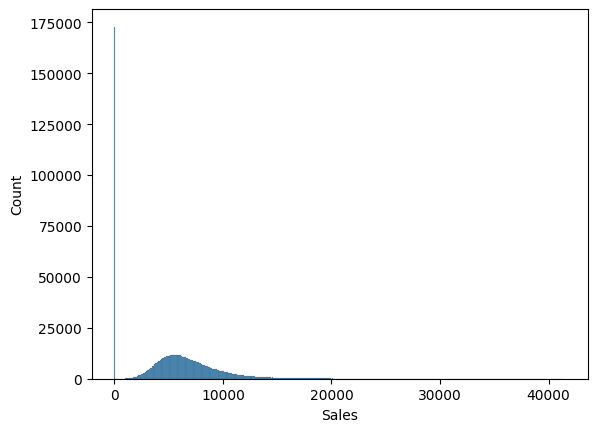

In [ ]:
sns.histplot(data = merged_df, x = "Sales");

In [ ]:
merged_df["Open"].value_counts()

,count
Open,
1,844392
0,172817


In [ ]:
merged_df = merged_df[merged_df["Open"] == 1].copy()

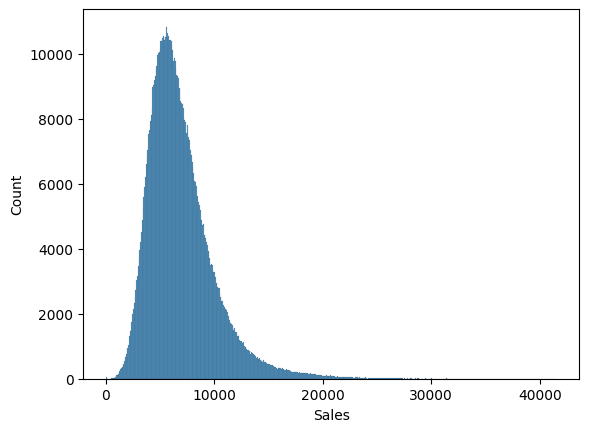

In [ ]:
sns.histplot(data = merged_df, x = "Sales");

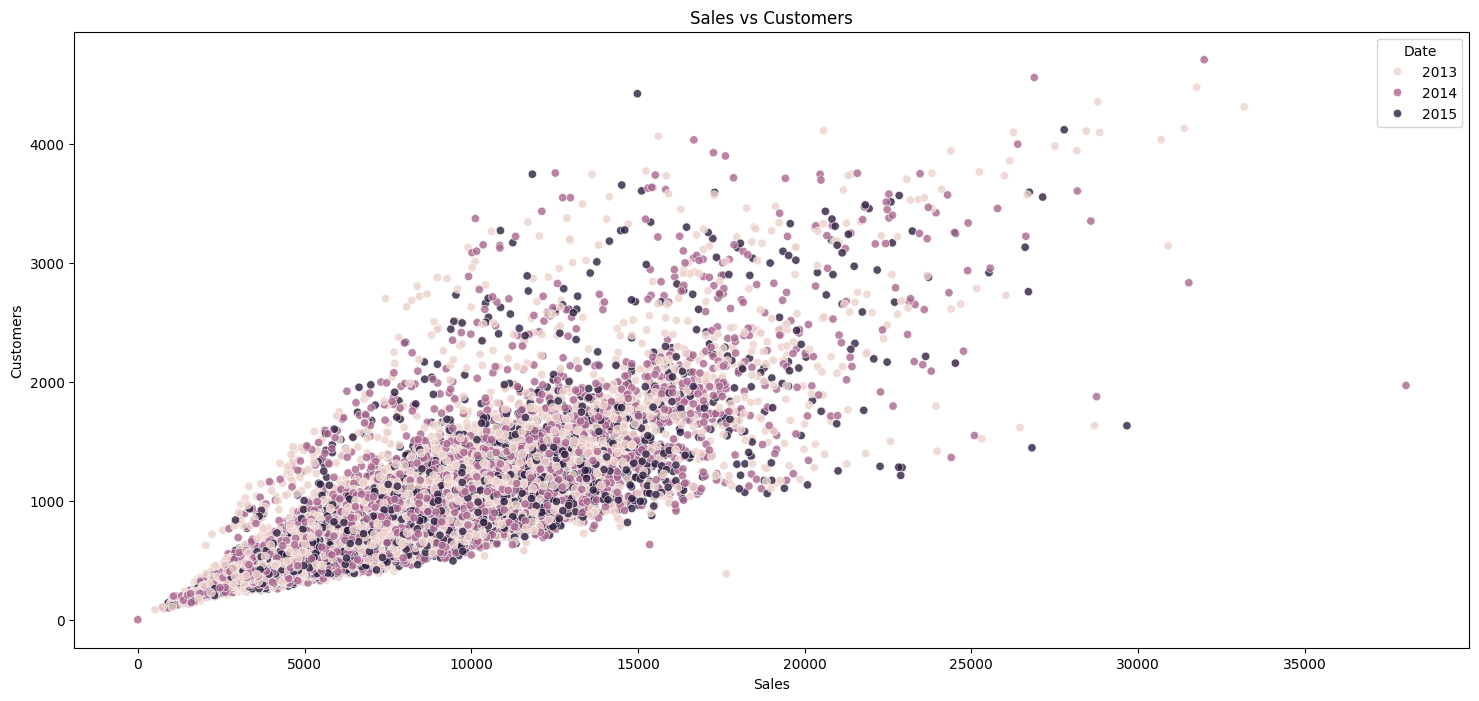

In [ ]:
plt.figure(figsize = (18, 8))
temp_df = merged_df.sample(40000)

sns.scatterplot(x = temp_df["Sales"], y = temp_df["Customers"], hue = temp_df.Date.dt.year, alpha = 0.8)
plt.title("Sales vs Customers")
plt.show()

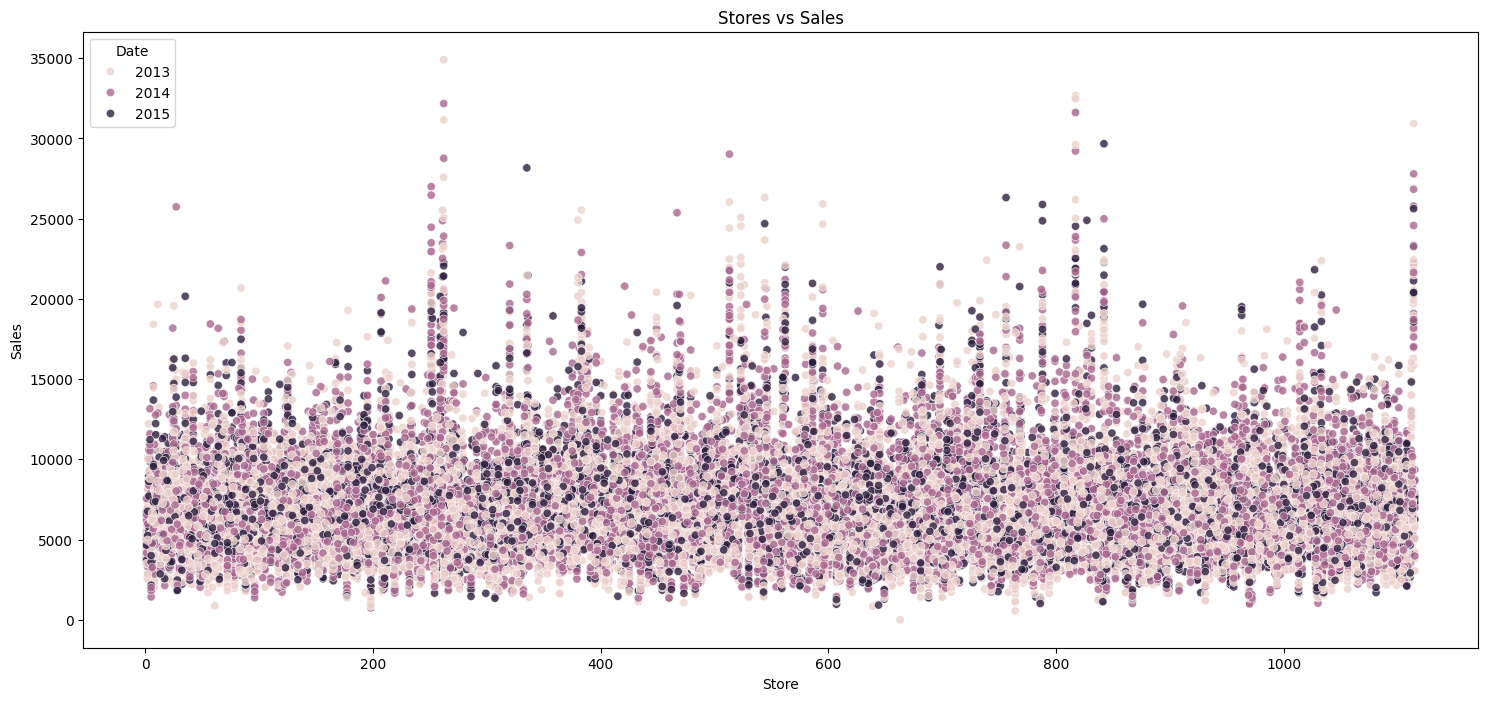

In [ ]:
plt.figure(figsize = (18, 8))
temp_df = merged_df.sample(40000)

sns.scatterplot(x = temp_df["Store"], y = temp_df["Sales"], hue = temp_df.Date.dt.year, alpha = 0.8)
plt.title("Stores vs Sales")
plt.show()

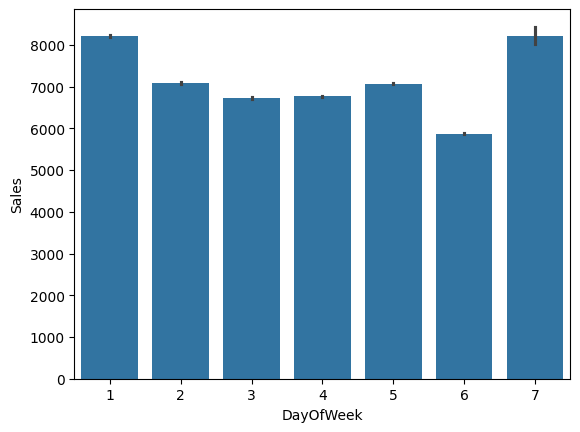

In [ ]:
sns.barplot(data = merged_df, x = "DayOfWeek", y = "Sales");

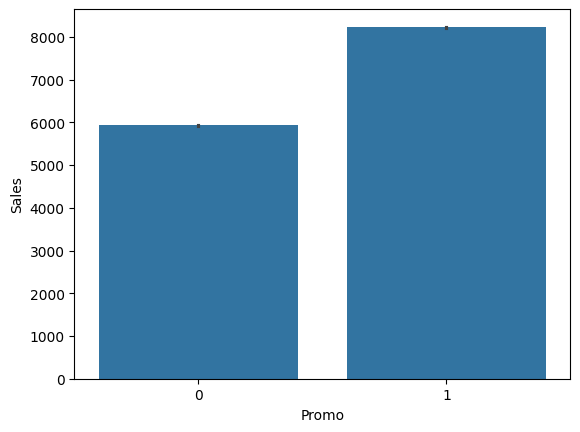

In [ ]:
sns.barplot(data = merged_df, x = "Promo", y = "Sales");

In [ ]:
merged_df.corr(numeric_only=True)["Sales"].sort_values(ascending = False)

,Sales
Sales,1.000000
Customers,0.823597
Promo,0.368145
Promo2SinceWeek,0.095311
SchoolHoliday,0.038617
CompetitionOpenSinceYear,0.016101
Store,0.007710
Promo2SinceYear,-0.034713
CompetitionDistance,-0.036396
CompetitionOpenSinceMonth,-0.043489


In [ ]:
merged_df["Day"] = merged_df.Date.dt.day
merged_df["Month"] = merged_df.Date.dt.month
merged_df["Year"] = merged_df.Date.dt.year

In [ ]:
merged_test_df["Day"] = merged_test_df.Date.dt.day
merged_test_df["Month"] = merged_test_df.Date.dt.month
merged_test_df["Year"] = merged_test_df.Date.dt.year

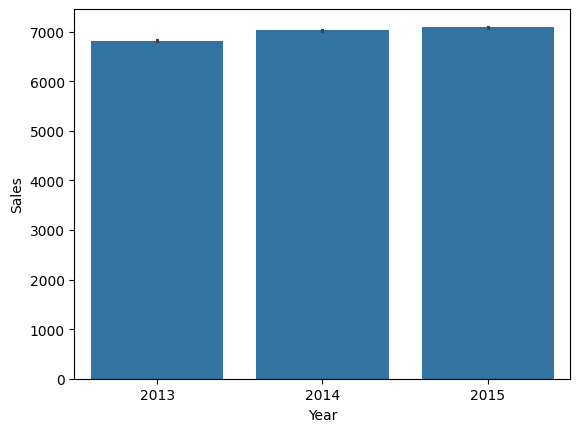

In [ ]:
sns.barplot(data = merged_df, x = "Year", y = "Sales");

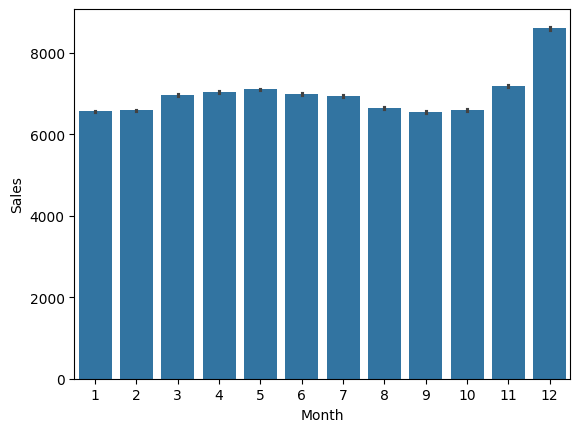

In [ ]:
sns.barplot(data = merged_df, x = "Month", y = "Sales");

In [ ]:
sales_and_stores_df = merged_df.groupby("Store")[["Customers", "Sales"]].agg("mean")
sales_and_stores_df

,Customers,Sales
Store,,
1,564.049936,4759.096031
2,583.998724,4953.900510
3,750.077022,6942.568678
4,1321.752551,9638.401786
5,537.340180,4676.274711
...,...,...
1111,451.711168,5251.702182
1112,838.608472,10236.577664
1113,717.029337,6627.859694


In [ ]:
sales_and_stores_df.plot(kind = "line")

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  object        
 10  Assortment                 844392 non-null  object        
 11  CompetitionDistance        842206 non-null  float64     

## 3. Train, Validation and Test Split

In [ ]:
train_size = int(0.75 * len(merged_df))

sorted_df = merged_df.sort_values("Date")
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]
len(train_df), len(val_df)

(633294, 211098)

In [ ]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,720.0,3.0,2002.0,0,NaN,NaN,NaN,1,1,2013
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,...,1870.0,10.0,2011.0,0,NaN,NaN,NaN,1,1,2013
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,...,210.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,...,1180.0,5.0,2013.0,0,NaN,NaN,NaN,1,1,2013
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,...,3640.0,NaN,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",1,1,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,745,3,2014-12-10,6897,657,1,0,0,0,a,...,17650.0,11.0,2013.0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",10,12,2014
256642,756,3,2014-12-10,15736,2292,1,0,0,0,a,...,50.0,NaN,NaN,1,40.0,2011.0,"Jan,Apr,Jul,Oct",10,12,2014
256634,747,3,2014-12-10,7444,608,1,0,0,0,c,...,45740.0,8.0,2008.0,0,NaN,NaN,NaN,10,12,2014
256633,746,3,2014-12-10,5207,474,1,0,0,0,d,...,4330.0,2.0,2011.0,1,35.0,2011.0,"Mar,Jun,Sept,Dec",10,12,2014


In [ ]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year'],
      dtype='object')

In [ ]:
# input_cols = ["Store", "DayOfWeek", "Date", "Sales", "Customers", "Open", "Promo",
#               "StateHoliday", "SchoolHoliday", "StoreType", "Assortment",
#               "CompetitionDistance", "CompetitionOpenSinceMonth",
#               "CompetitionOpenSinceYear", "Promo2", "Promo2SinceWeek",
#               "Promo2SinceYear", "PromoInterval", "Day", "Month", "Year"]

In [ ]:
input_cols = ["Store", "DayOfWeek", "Promo", "StateHoliday", "StoreType", "Assortment", "Day", "Month", "Year"]
target_col = "Sales"

In [ ]:
merged_df[input_cols].nunique()         # Feature Engineering should be applied to the Num of Stores; Else a curse of dimensionality problem will occurs

,0
Store,1115
DayOfWeek,7
Promo,2
StateHoliday,4
StoreType,4
Assortment,3
Day,31
Month,12
Year,3


In [ ]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [ ]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [ ]:
test_inputs = merged_test_df[input_cols].copy()

In [ ]:
numeric_cols = ["Store", "Day", "Month", "Year"]
categorical_cols = ["DayOfWeek", "Promo", "StateHoliday", "StoreType", "Assortment"]

## 4. Pre-processing

### 4.1 Impute Values

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy = "mean").fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

### 4.2 Scale

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

### 4.3 Encode One-Hot Vector

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output = False, handle_unknown = "ignore").fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [ ]:
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'Promo_0',
 'Promo_1',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [ ]:
train_inputs = pd.concat([train_inputs[numeric_cols], pd.DataFrame(encoder.transform(train_inputs[categorical_cols]), columns = encoded_cols, index = train_inputs.index)], axis = 1)
val_inputs = pd.concat([val_inputs[numeric_cols], pd.DataFrame(encoder.transform(val_inputs[categorical_cols]), columns = encoded_cols, index = val_inputs.index)], axis = 1)
test_inputs = pd.concat([test_inputs[numeric_cols], pd.DataFrame(encoder.transform(test_inputs[categorical_cols]), columns = encoded_cols, index = test_inputs.index)], axis = 1)

In [ ]:
train_inputs

,Store,Day,Month,Year,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
1017190,0.983842,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016179,0.075404,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016353,0.231598,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016356,0.234291,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016368,0.245063,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,0.667864,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
256642,0.677738,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
256634,0.669659,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
256633,0.668761,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

## 5. Base Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
linear_regression_model = LinearRegression().fit(X_train, train_targets)

In [ ]:
train_preds = linear_regression_model.predict(X_train)
val_preds= linear_regression_model.predict(X_val)

train_preds

array([ 7115.08762455, 10581.38651873,  7036.39236244, ...,
        6241.95353708,  5997.17125059,  5618.95124099])

In [ ]:
np.sqrt(mean_squared_error(train_preds, train_targets))     # You need sqrt function for RMSE

np.float64(2741.587191916578)

In [ ]:
np.sqrt(mean_squared_error(val_preds, val_targets))

np.float64(2817.7797940117125)

## 6. More Complex Models

### 6.1 `try_model` Function

In [ ]:
def try_model(model):
    model.fit(X_train, train_targets)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
    val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))

    return train_rmse, val_rmse

In [ ]:
try_model(linear_regression_model)

(np.float64(2741.587191916578), np.float64(2817.7797940117125))

### 6.2 Linear Models

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [ ]:
try_model(LinearRegression())

(np.float64(2741.587191916578), np.float64(2817.7797940117125))

In [ ]:
try_model(Ridge())

(np.float64(2741.5871950814444), np.float64(2817.7784665409868))

In [ ]:
try_model(Lasso())

(np.float64(2741.7143904640566), np.float64(2817.9472924045217))

In [ ]:
try_model(ElasticNet())

(np.float64(2879.0432103903954), np.float64(2972.6658860503385))

In [ ]:
try_model(SGDRegressor())

(np.float64(2742.345403756131), np.float64(2825.480349259378))

## 6.3 Tree Based Models

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
decision_tree_model = DecisionTreeRegressor(random_state = 42)
try_model(decision_tree_model)          # The model overfits

(np.float64(0.0), np.float64(1559.7378600480247))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
random_forest_model = RandomForestRegressor(n_estimators = 50, random_state = 42, n_jobs = -1)
try_model(random_forest_model)
# (np.float64(474.9198974666898), np.float64(1371.7321923469985))       n_estimators = 100

(np.float64(487.012426216983), np.float64(1379.0526396684656))

In [ ]:
random_forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

## 7. Interpret the Results

In [ ]:
X_train.columns

Index(['Store', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')

In [ ]:
random_forest_model.feature_importances_

array([6.07412101e-01, 4.88393196e-02, 4.71254150e-02, 9.30282826e-03,
       3.36941035e-02, 4.40591456e-03, 2.43735761e-03, 2.11467096e-03,
       5.71418981e-03, 6.96554452e-03, 4.47739863e-03, 5.83469269e-02,
       8.05201285e-02, 1.18767484e-03, 2.11472202e-04, 2.45172539e-05,
       1.88388455e-05, 1.38995265e-02, 2.25678813e-02, 1.04169805e-02,
       1.39945667e-02, 8.34303630e-03, 5.50125164e-03, 1.24783549e-02])

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": random_forest_model.feature_importances_
})

importance_df.sort_values("importance", ascending = False, inplace = True)
#importance_df.head(15)

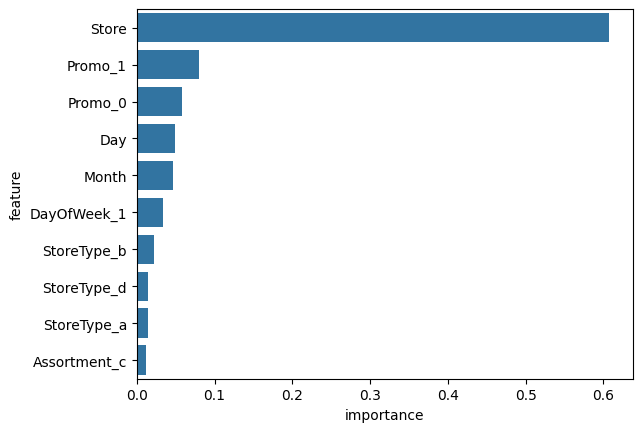

In [ ]:
sns.barplot(data = importance_df.head(10), x = "importance", y = "feature");

## 8. Submission on Kaggle

In [ ]:
test_preds = decision_tree_model.predict(X_test)
test_preds

array([ 3740.,  7563.,  8645., ...,  5847., 21594.,  6455.])

In [ ]:
submission_df = pd.read_csv("/content/rossmann-store-sales/sample_submission.csv")

In [ ]:
submission_df["Sales"] = test_df["Open"].fillna(1).astype("int") * test_preds
submission_df

,Id,Sales
0,1,3740.0
1,2,7563.0
2,3,8645.0
3,4,6552.0
4,5,6750.0
...,...,...
41083,41084,2801.0
41084,41085,7331.0
41085,41086,5847.0
41086,41087,21594.0


In [ ]:
submission_df.to_csv("submission.csv", index = None)

In [ ]:
!head submission.csv

Id,Sales
1,3740.0
2,7563.0
3,8645.0
4,6552.0
5,6750.0
6,5714.0
7,7915.0
8,8322.0
9,5620.0
